Notes(What needs to be done): 
1. for claim frequency Check var/ mean ratio(Coefficent of variation) to narrow candidates (initial list: Poisson, Negative Binomial, Binomial, Zero-Inflated Poisson, Zero inflated negative binomial, Poisson-Inverse Gaussian)
2. check what predictors are available at underwriting time(not rating)
etc

# 04 - Frequency

**Purpose:** Model claim frequency for each of the four coverages. Covers the
marginal count distribution, one-way frequency relationships, and the fitted
Poisson GLM with validation.

**Input:** `data/processed/frequency_data.csv`
**Output:** Figures to `outputs/figures/`. Fitted model objects held in memory.
**Depends on:** 02_Cleaned_Data, 03_Exploratory_Data_Analysis

**Sections**

1. Marginal distribution of `claim_count` by coverage
2. Distribution family selection (dispersion, zeros, AIC/BIC, GOF)
3. One-way frequency by predictor
4. Credibility: claim counts per cell
5. Poisson GLM fitting and variable selection
6. Validation on the holdout set

**Author:** Dalton | **Last run:** 2026-09-26

analyze var / mean and get candidate distibutions

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
PROC = ROOT / "data" / "processed"
FIGS = ROOT / "outputs" / "figures"

freq = pd.read_csv(PROC / "frequency_data.csv")

COVERAGES = ['Personal Property', 'Additional Living Expense',
             'Guest Medical', 'Liability']

fq = {c: freq[freq.coverage == c].reset_index(drop=True) for c in COVERAGES}

{c: len(d) for c, d in fq.items()}

{'Personal Property': 10000,
 'Additional Living Expense': 10000,
 'Guest Medical': 10000,
 'Liability': 10000}

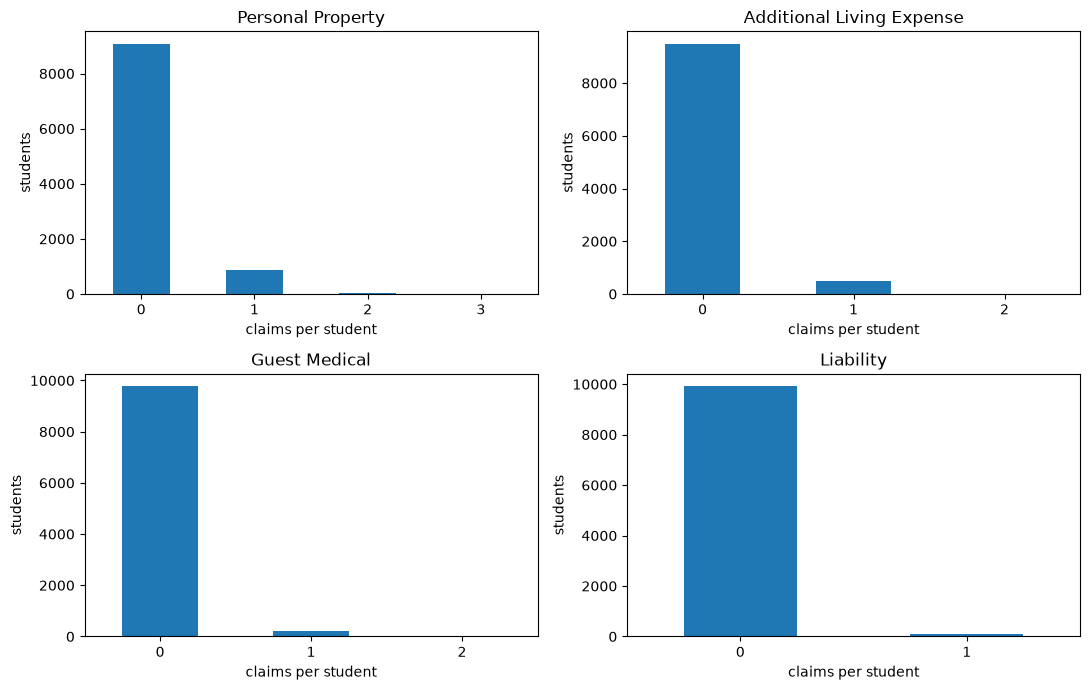

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, cov in zip(axes.flat, COVERAGES):
    d = fq[cov].claim_count
    d.value_counts().sort_index().plot.bar(ax=ax, rot=0, color='#1f77b4')
    ax.set_title(cov)
    ax.set_xlabel('claims per student')
    ax.set_ylabel('students')

plt.tight_layout()

Analyze BIC and AIC of each proposed distribution, an optimizer is used to get a numerical estimate of the MLE of each distribution

In [15]:
from scipy import stats, optimize

y    = fq['Personal Property'].claim_count.values
n    = len(y)
ybar = y.mean()

results = {}

def fit(nll, x0, k):
    r = optimize.minimize(nll, x0, method='Nelder-Mead',
                          options={'xatol':1e-8, 'fatol':1e-8, 'maxiter':5000})
    return -r.fun, k

results['Poisson'] = (stats.poisson.logpmf(y, ybar).sum(), 1)

def nll_zip(t):
    lam = np.exp(t[0]); pi = 1/(1+np.exp(-t[1]))
    return -np.where(y == 0,
                     np.log(pi + (1-pi)*np.exp(-lam)),
                     np.log1p(-pi) + stats.poisson.logpmf(y, lam)).sum()
results['ZIP'] = fit(nll_zip, [np.log(ybar), -2.0], 2)

def nb_lpmf(y, mu, a):
    r = 1/a
    return stats.nbinom.logpmf(y, r, r/(r+mu))

def nll_nb(t):
    return -nb_lpmf(y, np.exp(t[0]), np.exp(t[1])).sum()
results['NegBinomial'] = fit(nll_nb, [np.log(ybar), np.log(0.5)], 2)

def nll_zinb(t):
    mu, a = np.exp(t[0]), np.exp(t[1]); pi = 1/(1+np.exp(-t[2]))
    r  = 1/a
    p0 = stats.nbinom.pmf(0, r, r/(r+mu))
    return -np.where(y == 0,
                     np.log(pi + (1-pi)*p0),
                     np.log1p(-pi) + nb_lpmf(y, mu, a)).sum()
results['ZINB'] = fit(nll_zinb, [np.log(ybar), np.log(0.5), -2.0], 3)

tbl = pd.DataFrame(
    [(name, ll, k, 2*k - 2*ll, k*np.log(n) - 2*ll)
     for name, (ll, k) in results.items()],
    columns=['model', 'loglik', 'k', 'AIC', 'BIC']
).sort_values('BIC', ascending = False)

tbl.round(2)

,model,loglik,k,AIC,BIC
3,ZINB,-3276.18,3,6558.36,6579.99
1,ZIP,-3276.29,2,6556.59,6571.01
2,NegBinomial,-3276.18,2,6556.36,6570.78
0,Poisson,-3276.61,1,6555.23,6562.44


Based on the above table, possoin has the lowest bic and thus we will assume that personal property claim frequency follows a poisson distribution

Additional Living Expense

In [16]:
from scipy import stats, optimize

y    = fq['Additional Living Expense'].claim_count.values
n    = len(y)
ybar = y.mean()

results = {}

def fit(nll, x0, k):
    r = optimize.minimize(nll, x0, method='Nelder-Mead',
                          options={'xatol':1e-8, 'fatol':1e-8, 'maxiter':5000})
    return -r.fun, k

results['Poisson'] = (stats.poisson.logpmf(y, ybar).sum(), 1)

def nll_zip(t):
    lam = np.exp(t[0]); pi = 1/(1+np.exp(-t[1]))
    return -np.where(y == 0,
                     np.log(pi + (1-pi)*np.exp(-lam)),
                     np.log1p(-pi) + stats.poisson.logpmf(y, lam)).sum()
results['ZIP'] = fit(nll_zip, [np.log(ybar), -2.0], 2)

def nb_lpmf(y, mu, a):
    r = 1/a
    return stats.nbinom.logpmf(y, r, r/(r+mu))

def nll_nb(t):
    return -nb_lpmf(y, np.exp(t[0]), np.exp(t[1])).sum()
results['NegBinomial'] = fit(nll_nb, [np.log(ybar), np.log(0.5)], 2)

def nll_zinb(t):
    mu, a = np.exp(t[0]), np.exp(t[1]); pi = 1/(1+np.exp(-t[2]))
    r  = 1/a
    p0 = stats.nbinom.pmf(0, r, r/(r+mu))
    return -np.where(y == 0,
                     np.log(pi + (1-pi)*p0),
                     np.log1p(-pi) + nb_lpmf(y, mu, a)).sum()
results['ZINB'] = fit(nll_zinb, [np.log(ybar), np.log(0.5), -2.0], 3)

tbl = pd.DataFrame(
    [(name, ll, k, 2*k - 2*ll, k*np.log(n) - 2*ll)
     for name, (ll, k) in results.items()],
    columns=['model', 'loglik', 'k', 'AIC', 'BIC']
).sort_values('BIC', ascending = False)

tbl.round(2)

,model,loglik,k,AIC,BIC
3,ZINB,-2091.87,3,4189.74,4211.37
2,NegBinomial,-2091.92,2,4187.83,4202.25
1,ZIP,-2091.87,2,4187.74,4202.16
0,Poisson,-2092.07,1,4186.13,4193.34


Guest Medical 

In [17]:
from scipy import stats, optimize

y    = fq['Guest Medical'].claim_count.values
n    = len(y)
ybar = y.mean()

results = {}

def fit(nll, x0, k):
    r = optimize.minimize(nll, x0, method='Nelder-Mead',
                          options={'xatol':1e-8, 'fatol':1e-8, 'maxiter':5000})
    return -r.fun, k

results['Poisson'] = (stats.poisson.logpmf(y, ybar).sum(), 1)

def nll_zip(t):
    lam = np.exp(t[0]); pi = 1/(1+np.exp(-t[1]))
    return -np.where(y == 0,
                     np.log(pi + (1-pi)*np.exp(-lam)),
                     np.log1p(-pi) + stats.poisson.logpmf(y, lam)).sum()
results['ZIP'] = fit(nll_zip, [np.log(ybar), -2.0], 2)

def nb_lpmf(y, mu, a):
    r = 1/a
    return stats.nbinom.logpmf(y, r, r/(r+mu))

def nll_nb(t):
    return -nb_lpmf(y, np.exp(t[0]), np.exp(t[1])).sum()
results['NegBinomial'] = fit(nll_nb, [np.log(ybar), np.log(0.5)], 2)

def nll_zinb(t):
    mu, a = np.exp(t[0]), np.exp(t[1]); pi = 1/(1+np.exp(-t[2]))
    r  = 1/a
    p0 = stats.nbinom.pmf(0, r, r/(r+mu))
    return -np.where(y == 0,
                     np.log(pi + (1-pi)*p0),
                     np.log1p(-pi) + nb_lpmf(y, mu, a)).sum()
results['ZINB'] = fit(nll_zinb, [np.log(ybar), np.log(0.5), -2.0], 3)

tbl = pd.DataFrame(
    [(name, ll, k, 2*k - 2*ll, k*np.log(n) - 2*ll)
     for name, (ll, k) in results.items()],
    columns=['model', 'loglik', 'k', 'AIC', 'BIC']
).sort_values('BIC', ascending = False)

tbl.round(2)

,model,loglik,k,AIC,BIC
3,ZINB,-1111.40,3,2228.81,2250.44
2,NegBinomial,-1111.42,2,2226.84,2241.26
1,ZIP,-1111.40,2,2226.81,2241.23
0,Poisson,-1111.69,1,2225.38,2232.59


Liability

In [18]:
from scipy import stats, optimize

y    = fq['Liability'].claim_count.values
n    = len(y)
ybar = y.mean()

results = {}

def fit(nll, x0, k):
    r = optimize.minimize(nll, x0, method='Nelder-Mead',
                          options={'xatol':1e-8, 'fatol':1e-8, 'maxiter':5000})
    return -r.fun, k

results['Poisson'] = (stats.poisson.logpmf(y, ybar).sum(), 1)

def nll_zip(t):
    lam = np.exp(t[0]); pi = 1/(1+np.exp(-t[1]))
    return -np.where(y == 0,
                     np.log(pi + (1-pi)*np.exp(-lam)),
                     np.log1p(-pi) + stats.poisson.logpmf(y, lam)).sum()
results['ZIP'] = fit(nll_zip, [np.log(ybar), -2.0], 2)

def nb_lpmf(y, mu, a):
    r = 1/a
    return stats.nbinom.logpmf(y, r, r/(r+mu))

def nll_nb(t):
    return -nb_lpmf(y, np.exp(t[0]), np.exp(t[1])).sum()
results['NegBinomial'] = fit(nll_nb, [np.log(ybar), np.log(0.5)], 2)

def nll_zinb(t):
    mu, a = np.exp(t[0]), np.exp(t[1]); pi = 1/(1+np.exp(-t[2]))
    r  = 1/a
    p0 = stats.nbinom.pmf(0, r, r/(r+mu))
    return -np.where(y == 0,
                     np.log(pi + (1-pi)*p0),
                     np.log1p(-pi) + nb_lpmf(y, mu, a)).sum()
results['ZINB'] = fit(nll_zinb, [np.log(ybar), np.log(0.5), -2.0], 3)

tbl = pd.DataFrame(
    [(name, ll, k, 2*k - 2*ll, k*np.log(n) - 2*ll)
     for name, (ll, k) in results.items()],
    columns=['model', 'loglik', 'k', 'AIC', 'BIC']
).sort_values('BIC', ascending = False)

tbl.round(2)

,model,loglik,k,AIC,BIC
3,ZINB,-490.25,3,986.51,1008.14
1,ZIP,-490.25,2,984.51,998.93
2,NegBinomial,-490.25,2,984.51,998.93
0,Poisson,-490.25,1,982.51,989.72
